In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/Users/maximilianheil/OMSCS/finmmeval-task3-2026 copy


# Comprehensive EDA: TSLA and BTC Trading Data

This notebook performs exploratory data analysis on Tesla (TSLA) stock and Bitcoin (BTC) trading data, including price movements and news coverage.

In [2]:
from decision_making.data import load_data
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

# Set up plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

In [3]:
# Load data
tsla = load_data(symbol="TSLA", download_if_missing=False)
btc = load_data(symbol="BTC", download_if_missing=False)

## 1. Data Overview and Quality Assessment

In [4]:
# Display TSLA data (first row)
tsla.head(1)

date,asset,prices,news
str,str,f64,list[str]
"""2024-08-01""","""TSLA""",216.860001,"[""The provided TSLA coverage from August 1, 2024 centers on a two-day snapshot of price action and trading activity, paired with a narrow note on social-media sentiment. The core message is one of notable volatility amid rising trading volume, with a hint of bearish sentiment in online chatter but no explicit sentiment scoring in the article. Trading activity and price action - July 31 session (data from statmuse cited in the article): Tesla opened at 227.90, reached a high of 234.68, a low of 226.79, and closed at 232.07. The trading volume was about 67.5 million shares. - August 1 session: The stock opened at 227.69, climbed to a intraday high of 231.87, then dropped to a low of 214.33, before settling at 216.86. Volume for this day was higher, at roughly 83.9 million shares. - In terms of momentum over the two days, the August 1 close (216.86) was lower than the July 31 close (232.07), indicating a negative move from end-of-day July 31 to the end of August 1 despite the intraday rebound. The intraday range on August 1 was substantial, signaling increased intraday volatility (low of 214.33 and high of 231.87). Trading activity themes - Volume dynamics: August 1 saw a notable uptick in volume relative to July 31 (about 83.9 million vs. 67.5 million), suggesting greater trading participation on the second day of the window. - Price range and direction: The two-day window shows a sharp intraday swing on August 1, with a wide range between 214.33 and 231.87, and a net decline by the day’s close from the prior session. Sentiment signals - Social media signal: A July 30 Patreon post referenced a tightening red ribbon in the stock’s chart, implying a potential downtrend. This represents a bearish reading from social chatter within the article’s context. - Overall sentiment scoring: The article itself assigns no explicit sentiment score (N/A). The presence of the Patreon note suggests some bearish sentiment in external commentary, but there is no quantified sentiment conclusion in the article. Key themes and developments - Short-term volatility: The data show a volatile two-day window with a broad intraday range on August 1, highlighting amplified intraday price movement. - Increased participation: A rise in trading volume on August 1 points to higher market activity during this period. - Bearish sentiment cues from social media: The referenced Patreon post points to potential downside bias in external discussions, suggesting that some market participants perceived signs of a downtrend, even if the article itself does not quantify sentiment. - Absence of explicit catalysts: The article provides price and volume data and a minimal social sentiment cue but does not present catalysts, news events, or guidance that would explain the price action beyond the data shown. Overall market sentiment based on these articles - The two-day snapshot conveys cautious-to-bearish tone within the limited scope of the article. The August 1 close of 216.86 is notably lower than the July 31 close of 232.07, indicating negative near-term momentum on those dates. The social-media cue about a potential downtrend reinforces a bearish tilt in external chatter, though the article does not quantify an aggregate sentiment score. The absence of explicit catalysts or positive triggers in the piece further reinforces a cautious or modestly bearish interpretation of this short window, with the notable intraday volatility implying unsettled trading dynamics rather than a clear directional consensus. Sources referenced include the price and volume data attributed to statmuse and the note about social-media sentiment tied to a July 30 Patreon post.""]"


In [5]:
# Display BTC data (first row)
btc.head(1)

shape: (1, 4)
┌────────────┬───────┬──────────┬─────────────────────────────────┐
│ date       ┆ asset ┆ prices   ┆ news                            │
│ ---        ┆ ---   ┆ ---      ┆ ---                             │
│ str        ┆ str   ┆ f64      ┆ list[str]                       │
╞════════════╪═══════╪══════════╪═════════════════════════════════╡
│ 2024-08-01 ┆ BTC   ┆ 65392.96 ┆ ["Across the set of BTC-focuse… │
└────────────┴───────┴──────────┴─────────────────────────────────┘

In [6]:
# Data shape and structure
print("TSLA Dataset:")
print(f"  Shape: {tsla.shape}")
print(f"  Columns: {tsla.columns}")
print(f"  Date range: {tsla['date'].min()} to {tsla['date'].max()}")
print("\nBTC Dataset:")
print(f"  Shape: {btc.shape}")
print(f"  Columns: {btc.columns}")
print(f"  Date range: {btc['date'].min()} to {btc['date'].max()}")

TSLA Dataset:
  Shape: (528, 4)
  Columns: ['date', 'asset', 'prices', 'news']
  Date range: 2024-08-01 to 2026-01-10

BTC Dataset:
  Shape: (528, 4)
  Columns: ['date', 'asset', 'prices', 'news']
  Date range: 2024-08-01 to 2026-01-10


In [7]:
# Check for missing values and duplicates
print("TSLA Missing Values:")
print(tsla.null_count())
print(f"\nTSLA Duplicate dates: {tsla['date'].n_unique()} unique out of {tsla.shape[0]} total")

print("\n" + "=" * 50)
print("\nBTC Missing Values:")
print(btc.null_count())
print(f"\nBTC Duplicate dates: {btc['date'].n_unique()} unique out of {btc.shape[0]} total")

TSLA Missing Values:
shape: (1, 4)
┌──────┬───────┬────────┬──────┐
│ date ┆ asset ┆ prices ┆ news │
│ ---  ┆ ---   ┆ ---    ┆ ---  │
│ u32  ┆ u32   ┆ u32    ┆ u32  │
╞══════╪═══════╪════════╪══════╡
│ 0    ┆ 0     ┆ 0      ┆ 0    │
└──────┴───────┴────────┴──────┘

TSLA Duplicate dates: 528 unique out of 528 total


BTC Missing Values:
shape: (1, 4)
┌──────┬───────┬────────┬──────┐
│ date ┆ asset ┆ prices ┆ news │
│ ---  ┆ ---   ┆ ---    ┆ ---  │
│ u32  ┆ u32   ┆ u32    ┆ u32  │
╞══════╪═══════╪════════╪══════╡
│ 0    ┆ 0     ┆ 0      ┆ 0    │
└──────┴───────┴────────┴──────┘

BTC Duplicate dates: 528 unique out of 528 total


In [8]:
# Add news count column for easier analysis
tsla_analysis = tsla.with_columns(
    pl.col("news").list.len().alias("news_count"),
    pl.col("date").str.to_date().alias("date_parsed"),
)

btc_analysis = btc.with_columns(
    pl.col("news").list.len().alias("news_count"),
    pl.col("date").str.to_date().alias("date_parsed"),
)

print("Enhanced TSLA data:")
print(tsla_analysis.head())
print("\nEnhanced BTC data:")
print(btc_analysis.head())

Enhanced TSLA data:
shape: (5, 6)
┌────────────┬───────┬────────────┬─────────────────────────────────┬────────────┬─────────────┐
│ date       ┆ asset ┆ prices     ┆ news                            ┆ news_count ┆ date_parsed │
│ ---        ┆ ---   ┆ ---        ┆ ---                             ┆ ---        ┆ ---         │
│ str        ┆ str   ┆ f64        ┆ list[str]                       ┆ u32        ┆ date        │
╞════════════╪═══════╪════════════╪═════════════════════════════════╪════════════╪═════════════╡
│ 2024-08-01 ┆ TSLA  ┆ 216.860001 ┆ ["The provided TSLA coverage f… ┆ 1          ┆ 2024-08-01  │
│ 2024-08-02 ┆ TSLA  ┆ 207.669998 ┆ ["The provided TSLA-focused ar… ┆ 1          ┆ 2024-08-02  │
│ 2024-08-03 ┆ TSLA  ┆ 207.669998 ┆ ["Comprehensive summary         ┆ 1          ┆ 2024-08-03  │
│            ┆       ┆            ┆                                 ┆            ┆             │
│            ┆       ┆            ┆ The A…                          ┆            ┆           

## 2. Price Analysis

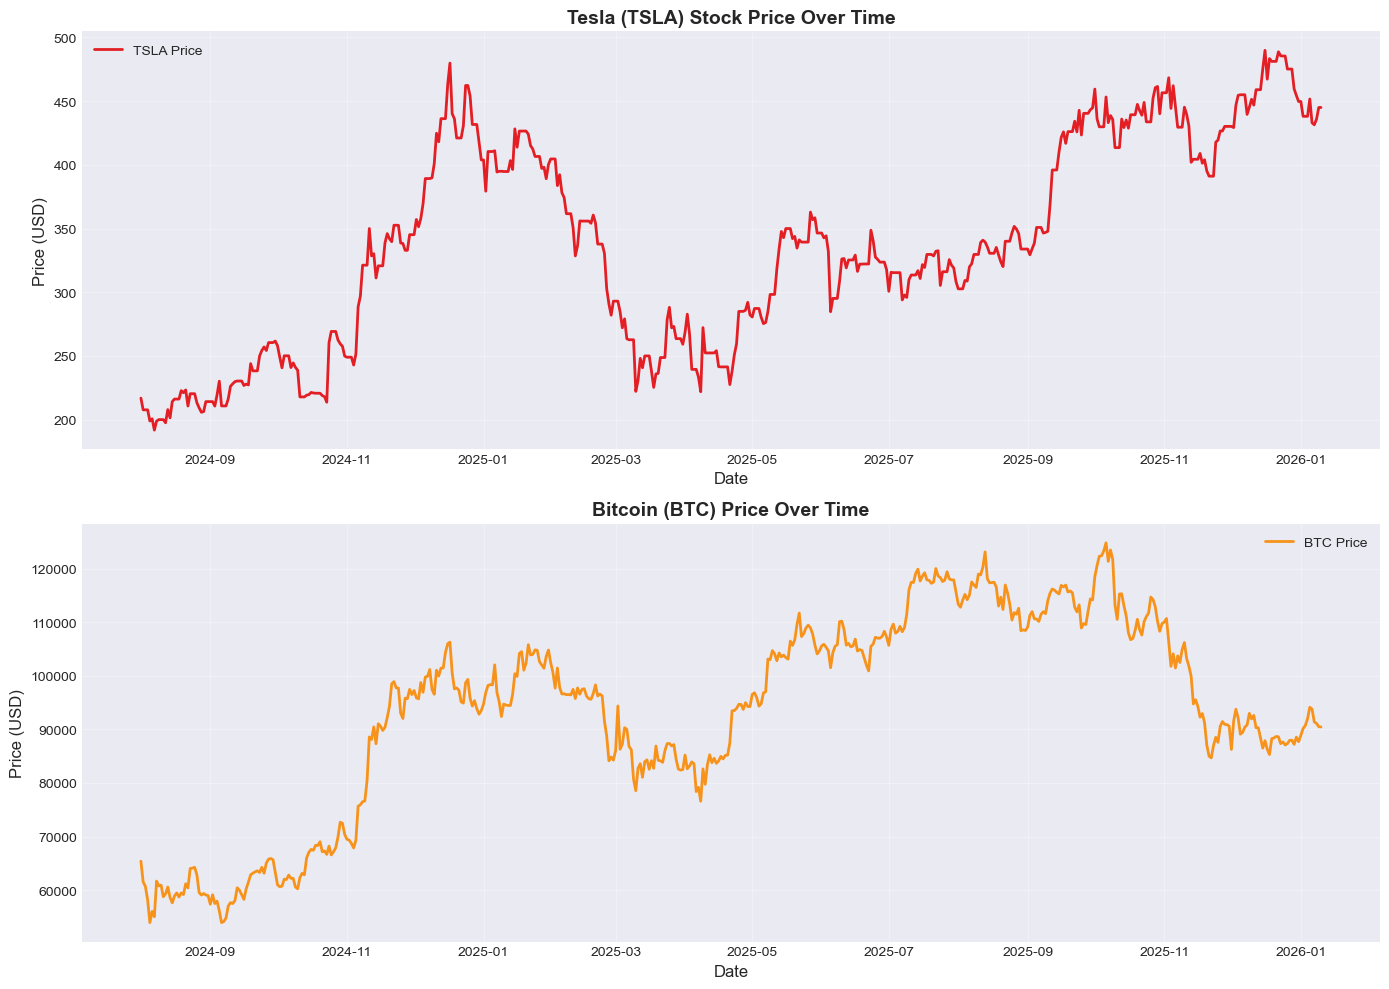

In [9]:
# Price trends over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# TSLA price trend
tsla_pd = tsla_analysis.to_pandas()
tsla_pd["date_parsed"] = pd.to_datetime(tsla_pd["date_parsed"])
ax1.plot(
    tsla_pd["date_parsed"],
    tsla_pd["prices"],
    linewidth=2,
    color="#E31E24",
    label="TSLA Price",
)
ax1.set_title("Tesla (TSLA) Stock Price Over Time", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Price (USD)", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# BTC price trend
btc_pd = btc_analysis.to_pandas()
btc_pd["date_parsed"] = pd.to_datetime(btc_pd["date_parsed"])
ax2.plot(
    btc_pd["date_parsed"],
    btc_pd["prices"],
    linewidth=2,
    color="#F7931A",
    label="BTC Price",
)
ax2.set_title("Bitcoin (BTC) Price Over Time", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Price (USD)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
# Price statistics summary
print("=" * 70)
print("TESLA (TSLA) PRICE STATISTICS")
print("=" * 70)
tsla_stats = tsla_analysis.select([
    pl.col("prices").min().alias("Min Price"),
    pl.col("prices").max().alias("Max Price"),
    pl.col("prices").mean().alias("Mean Price"),
    pl.col("prices").median().alias("Median Price"),
    pl.col("prices").std().alias("Std Dev"),
])
print(tsla_stats)

# Calculate price change
tsla_first = tsla_analysis.select("prices").head(1).item()
tsla_last = tsla_analysis.select("prices").tail(1).item()
tsla_change = ((tsla_last - tsla_first) / tsla_first) * 100
print(f"\nTotal Price Change: ${tsla_first:.2f} → ${tsla_last:.2f} ({tsla_change:+.2f}%)")

print("\n" + "=" * 70)
print("BITCOIN (BTC) PRICE STATISTICS")
print("=" * 70)
btc_stats = btc_analysis.select([
    pl.col("prices").min().alias("Min Price"),
    pl.col("prices").max().alias("Max Price"),
    pl.col("prices").mean().alias("Mean Price"),
    pl.col("prices").median().alias("Median Price"),
    pl.col("prices").std().alias("Std Dev"),
])
print(btc_stats)

# Calculate price change
btc_first = btc_analysis.select("prices").head(1).item()
btc_last = btc_analysis.select("prices").tail(1).item()
btc_change = ((btc_last - btc_first) / btc_first) * 100
print(f"\nTotal Price Change: ${btc_first:.2f} → ${btc_last:.2f} ({btc_change:+.2f}%)")

TESLA (TSLA) PRICE STATISTICS
shape: (1, 5)
┌────────────┬────────────┬────────────┬──────────────┬───────────┐
│ Min Price  ┆ Max Price  ┆ Mean Price ┆ Median Price ┆ Std Dev   │
│ ---        ┆ ---        ┆ ---        ┆ ---          ┆ ---       │
│ f64        ┆ f64        ┆ f64        ┆ f64          ┆ f64       │
╞════════════╪════════════╪════════════╪══════════════╪═══════════╡
│ 191.759995 ┆ 489.880005 ┆ 337.36714  ┆ 333.869995   ┆ 80.526194 │
└────────────┴────────────┴────────────┴──────────────┴───────────┘

Total Price Change: $216.86 → $445.01 (+105.21%)

BITCOIN (BTC) PRICE STATISTICS
shape: (1, 5)
┌───────────┬───────────┬──────────────┬──────────────┬──────────────┐
│ Min Price ┆ Max Price ┆ Mean Price   ┆ Median Price ┆ Std Dev      │
│ ---       ┆ ---       ┆ ---          ┆ ---          ┆ ---          │
│ f64       ┆ f64       ┆ f64          ┆ f64          ┆ f64          │
╞═══════════╪═══════════╪══════════════╪══════════════╪══════════════╡
│ 53944.07  ┆ 124797.86 ┆ 934

In [11]:
# Calculate daily returns and volatility
tsla_returns = tsla_analysis.with_columns(
    ((pl.col("prices") - pl.col("prices").shift(1)) / pl.col("prices").shift(1) * 100).alias("daily_return_pct")
)

btc_returns = btc_analysis.with_columns(
    ((pl.col("prices") - pl.col("prices").shift(1)) / pl.col("prices").shift(1) * 100).alias("daily_return_pct")
)

# Volatility statistics
print("=" * 70)
print("VOLATILITY ANALYSIS (Daily Returns %)")
print("=" * 70)
print("\nTSLA:")
print(
    tsla_returns.select([
        pl.col("daily_return_pct").mean().alias("Mean Daily Return %"),
        pl.col("daily_return_pct").std().alias("Volatility (Std Dev)"),
        pl.col("daily_return_pct").min().alias("Max Loss %"),
        pl.col("daily_return_pct").max().alias("Max Gain %"),
    ])
)

print("\nBTC:")
print(
    btc_returns.select([
        pl.col("daily_return_pct").mean().alias("Mean Daily Return %"),
        pl.col("daily_return_pct").std().alias("Volatility (Std Dev)"),
        pl.col("daily_return_pct").min().alias("Max Loss %"),
        pl.col("daily_return_pct").max().alias("Max Gain %"),
    ])
)

VOLATILITY ANALYSIS (Daily Returns %)

TSLA:
shape: (1, 4)
┌─────────────────────┬──────────────────────┬────────────┬────────────┐
│ Mean Daily Return % ┆ Volatility (Std Dev) ┆ Max Loss % ┆ Max Gain % │
│ ---                 ┆ ---                  ┆ ---        ┆ ---        │
│ f64                 ┆ f64                  ┆ f64        ┆ f64        │
╞═════════════════════╪══════════════════════╪════════════╪════════════╡
│ 0.193041            ┆ 3.395389             ┆ -15.426207 ┆ 22.68999   │
└─────────────────────┴──────────────────────┴────────────┴────────────┘

BTC:
shape: (1, 4)
┌─────────────────────┬──────────────────────┬────────────┬────────────┐
│ Mean Daily Return % ┆ Volatility (Std Dev) ┆ Max Loss % ┆ Max Gain % │
│ ---                 ┆ ---                  ┆ ---        ┆ ---        │
│ f64                 ┆ f64                  ┆ f64        ┆ f64        │
╞═════════════════════╪══════════════════════╪════════════╪════════════╡
│ 0.088913            ┆ 2.349044             

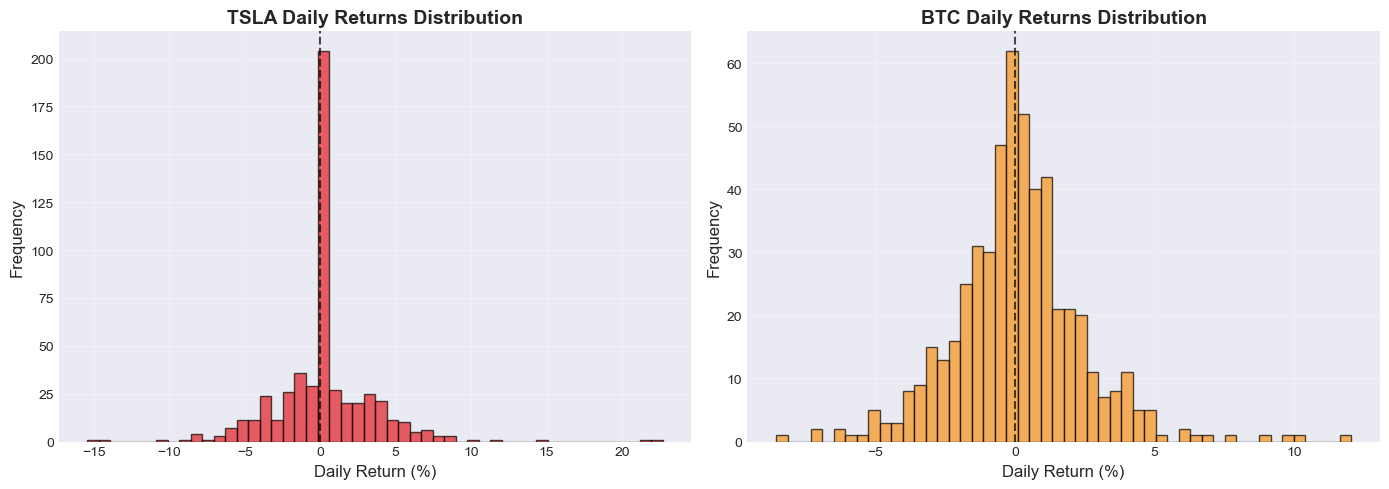

In [12]:
# Distribution of returns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# TSLA returns distribution
tsla_returns_clean = tsla_returns.filter(pl.col("daily_return_pct").is_not_null())
ax1.hist(
    tsla_returns_clean["daily_return_pct"].to_numpy(),
    bins=50,
    color="#E31E24",
    alpha=0.7,
    edgecolor="black",
)
ax1.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax1.set_title("TSLA Daily Returns Distribution", fontsize=14, fontweight="bold")
ax1.set_xlabel("Daily Return (%)", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.grid(True, alpha=0.3)

# BTC returns distribution
btc_returns_clean = btc_returns.filter(pl.col("daily_return_pct").is_not_null())
ax2.hist(
    btc_returns_clean["daily_return_pct"].to_numpy(),
    bins=50,
    color="#F7931A",
    alpha=0.7,
    edgecolor="black",
)
ax2.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.set_title("BTC Daily Returns Distribution", fontsize=14, fontweight="bold")
ax2.set_xlabel("Daily Return (%)", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. News Coverage Analysis

In [13]:
# News coverage statistics
print("=" * 70)
print("NEWS COVERAGE STATISTICS")
print("=" * 70)

print("\nTSLA News Coverage:")
print(
    tsla_analysis.select([
        pl.col("news_count").sum().alias("Total News Articles"),
        pl.col("news_count").mean().alias("Avg Articles per Day"),
        pl.col("news_count").median().alias("Median Articles per Day"),
        pl.col("news_count").min().alias("Min Articles per Day"),
        pl.col("news_count").max().alias("Max Articles per Day"),
    ])
)

print("\nBTC News Coverage:")
print(
    btc_analysis.select([
        pl.col("news_count").sum().alias("Total News Articles"),
        pl.col("news_count").mean().alias("Avg Articles per Day"),
        pl.col("news_count").median().alias("Median Articles per Day"),
        pl.col("news_count").min().alias("Min Articles per Day"),
        pl.col("news_count").max().alias("Max Articles per Day"),
    ])
)

NEWS COVERAGE STATISTICS

TSLA News Coverage:
shape: (1, 5)
┌────────────┬────────────────────────┬─────────────────┬──────────────────┬───────────────────────┐
│ Total News ┆ Avg Articles per Day   ┆ Median Articles ┆ Min Articles per ┆ Max Articles per Day  │
│ Articles   ┆ ---                    ┆ per Day         ┆ Day              ┆ ---                   │
│ ---        ┆ f64                    ┆ ---             ┆ ---              ┆ u32                   │
│ u32        ┆                        ┆ f64             ┆ u32              ┆                       │
╞════════════╪════════════════════════╪═════════════════╪══════════════════╪═══════════════════════╡
│ 531        ┆ 1.005682               ┆ 1.0             ┆ 1                ┆ 2                     │
└────────────┴────────────────────────┴─────────────────┴──────────────────┴───────────────────────┘

BTC News Coverage:
shape: (1, 5)
┌────────────┬────────────────────────┬─────────────────┬──────────────────┬──────────────────────

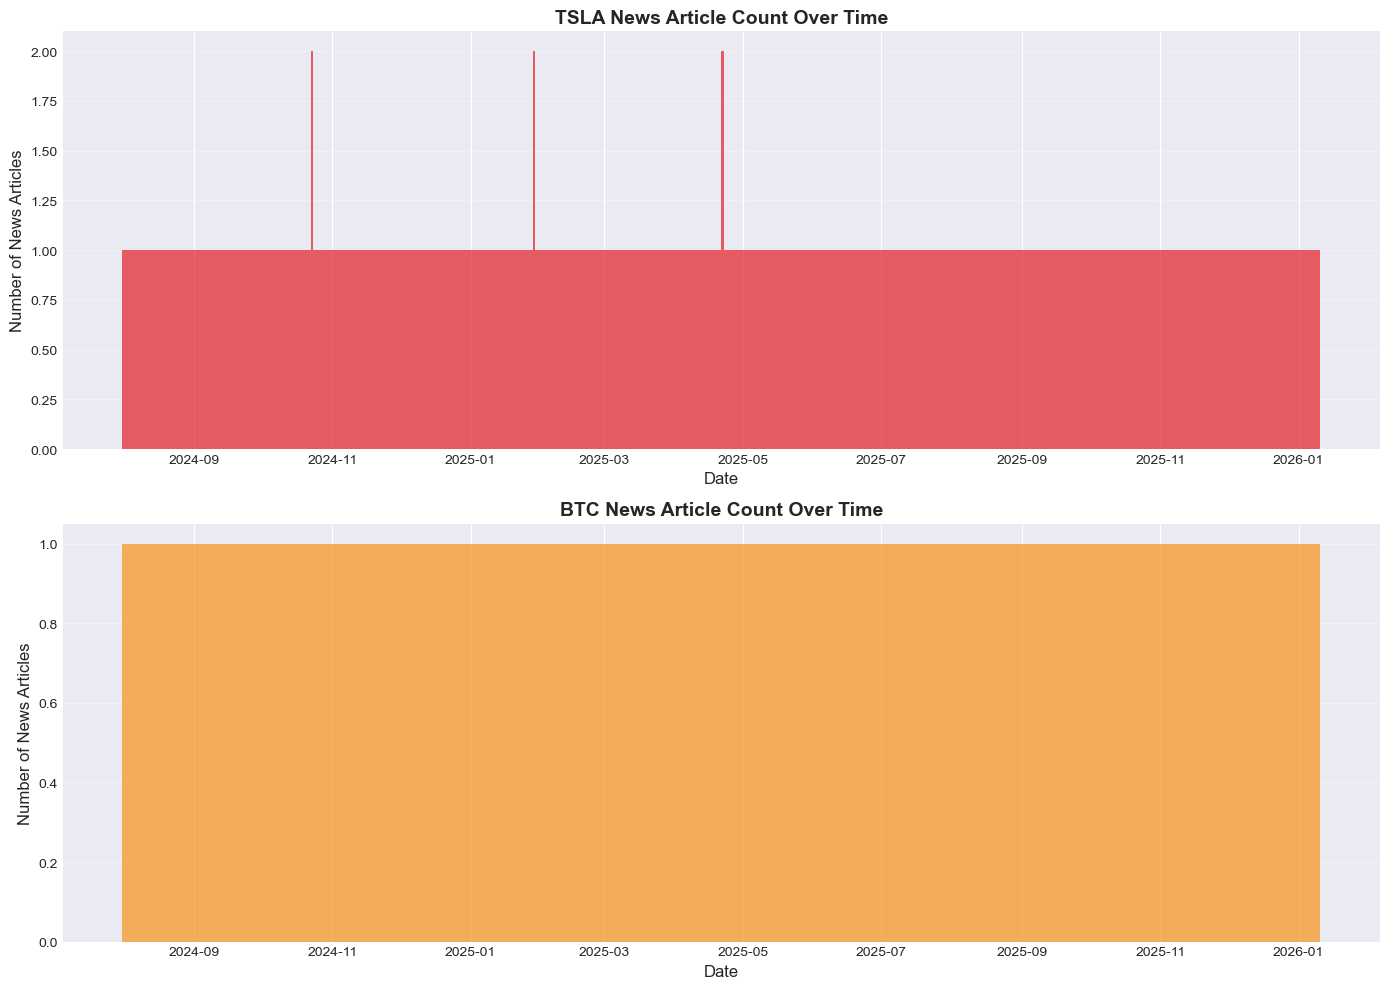

In [14]:
# News coverage over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# TSLA news coverage
ax1.bar(tsla_pd["date_parsed"], tsla_pd["news_count"], color="#E31E24", alpha=0.7, width=1)
ax1.set_title("TSLA News Article Count Over Time", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Number of News Articles", fontsize=12)
ax1.grid(True, alpha=0.3, axis="y")

# BTC news coverage
ax2.bar(btc_pd["date_parsed"], btc_pd["news_count"], color="#F7931A", alpha=0.7, width=1)
ax2.set_title("BTC News Article Count Over Time", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Number of News Articles", fontsize=12)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [15]:
# Top 10 days with most news coverage
print("=" * 70)
print("TOP 10 DAYS WITH MOST NEWS COVERAGE")
print("=" * 70)

print("\nTSLA:")
print(tsla_analysis.select(["date", "news_count", "prices"]).sort("news_count", descending=True).head(10))

print("\nBTC:")
print(btc_analysis.select(["date", "news_count", "prices"]).sort("news_count", descending=True).head(10))

TOP 10 DAYS WITH MOST NEWS COVERAGE

TSLA:
shape: (10, 3)
┌────────────┬────────────┬────────────┐
│ date       ┆ news_count ┆ prices     │
│ ---        ┆ ---        ┆ ---        │
│ str        ┆ u32        ┆ f64        │
╞════════════╪════════════╪════════════╡
│ 2024-10-23 ┆ 2          ┆ 213.649994 │
│ 2025-01-29 ┆ 2          ┆ 389.100006 │
│ 2025-04-22 ┆ 2          ┆ 237.970001 │
│ 2024-08-01 ┆ 1          ┆ 216.860001 │
│ 2024-08-02 ┆ 1          ┆ 207.669998 │
│ 2024-08-03 ┆ 1          ┆ 207.669998 │
│ 2024-08-04 ┆ 1          ┆ 207.669998 │
│ 2024-08-05 ┆ 1          ┆ 198.880005 │
│ 2024-08-06 ┆ 1          ┆ 200.639999 │
│ 2024-08-07 ┆ 1          ┆ 191.759995 │
└────────────┴────────────┴────────────┘

BTC:
shape: (10, 3)
┌────────────┬────────────┬──────────┐
│ date       ┆ news_count ┆ prices   │
│ ---        ┆ ---        ┆ ---      │
│ str        ┆ u32        ┆ f64      │
╞════════════╪════════════╪══════════╡
│ 2024-08-01 ┆ 1          ┆ 65392.96 │
│ 2024-08-02 ┆ 1          ┆ 615

## 4. News Content Analysis: Word/Token Counts

In [16]:
# Calculate word counts for each news article
def count_words_in_news(news_list):
    """Count total words across all news articles in a list"""
    total_words = 0
    for article in news_list:
        if article:  # Make sure article is not None or empty
            total_words += len(article.split())
    return total_words


# Add word count columns
tsla_words = tsla_analysis.with_columns(
    pl.col("news").map_elements(count_words_in_news, return_dtype=pl.Int64).alias("total_words")
)

btc_words = btc_analysis.with_columns(
    pl.col("news").map_elements(count_words_in_news, return_dtype=pl.Int64).alias("total_words")
)

print("TSLA with word counts:")
print(tsla_words.select(["date", "news_count", "total_words"]).head(10))
print("\nBTC with word counts:")
print(btc_words.select(["date", "news_count", "total_words"]).head(10))

TSLA with word counts:
shape: (10, 3)
┌────────────┬────────────┬─────────────┐
│ date       ┆ news_count ┆ total_words │
│ ---        ┆ ---        ┆ ---         │
│ str        ┆ u32        ┆ i64         │
╞════════════╪════════════╪═════════════╡
│ 2024-08-01 ┆ 1          ┆ 588         │
│ 2024-08-02 ┆ 1          ┆ 470         │
│ 2024-08-03 ┆ 1          ┆ 551         │
│ 2024-08-04 ┆ 1          ┆ 559         │
│ 2024-08-05 ┆ 1          ┆ 423         │
│ 2024-08-06 ┆ 1          ┆ 445         │
│ 2024-08-07 ┆ 1          ┆ 532         │
│ 2024-08-08 ┆ 1          ┆ 599         │
│ 2024-08-09 ┆ 1          ┆ 587         │
│ 2024-08-10 ┆ 1          ┆ 498         │
└────────────┴────────────┴─────────────┘

BTC with word counts:
shape: (10, 3)
┌────────────┬────────────┬─────────────┐
│ date       ┆ news_count ┆ total_words │
│ ---        ┆ ---        ┆ ---         │
│ str        ┆ u32        ┆ i64         │
╞════════════╪════════════╪═════════════╡
│ 2024-08-01 ┆ 1          ┆ 1257        │


In [17]:
# Word count statistics
print("=" * 70)
print("NEWS WORD COUNT STATISTICS")
print("=" * 70)

print("\nTSLA Word Counts:")
print(
    tsla_words.select([
        pl.col("total_words").sum().alias("Total Words"),
        pl.col("total_words").mean().alias("Avg Words per Day"),
        pl.col("total_words").median().alias("Median Words per Day"),
        pl.col("total_words").std().alias("Std Dev"),
        pl.col("total_words").min().alias("Min Words"),
        pl.col("total_words").max().alias("Max Words"),
    ])
)

print("\nBTC Word Counts:")
print(
    btc_words.select([
        pl.col("total_words").sum().alias("Total Words"),
        pl.col("total_words").mean().alias("Avg Words per Day"),
        pl.col("total_words").median().alias("Median Words per Day"),
        pl.col("total_words").std().alias("Std Dev"),
        pl.col("total_words").min().alias("Min Words"),
        pl.col("total_words").max().alias("Max Words"),
    ])
)

# Average words per article
print("\n" + "=" * 70)
print("AVERAGE WORDS PER ARTICLE")
print("=" * 70)
tsla_words_per_article = tsla_words["total_words"].sum() / tsla_words["news_count"].sum()
btc_words_per_article = btc_words["total_words"].sum() / btc_words["news_count"].sum()
print(f"TSLA: {tsla_words_per_article:.1f} words per article")
print(f"BTC:  {btc_words_per_article:.1f} words per article")

NEWS WORD COUNT STATISTICS

TSLA Word Counts:
shape: (1, 6)
┌─────────────┬───────────────────┬──────────────────────┬───────────┬───────────┬───────────┐
│ Total Words ┆ Avg Words per Day ┆ Median Words per Day ┆ Std Dev   ┆ Min Words ┆ Max Words │
│ ---         ┆ ---               ┆ ---                  ┆ ---       ┆ ---       ┆ ---       │
│ i64         ┆ f64               ┆ f64                  ┆ f64       ┆ i64       ┆ i64       │
╞═════════════╪═══════════════════╪══════════════════════╪═══════════╪═══════════╪═══════════╡
│ 525268      ┆ 994.825758        ┆ 1016.5               ┆ 292.86134 ┆ 297       ┆ 1815      │
└─────────────┴───────────────────┴──────────────────────┴───────────┴───────────┴───────────┘

BTC Word Counts:
shape: (1, 6)
┌─────────────┬───────────────────┬──────────────────────┬────────────┬───────────┬───────────┐
│ Total Words ┆ Avg Words per Day ┆ Median Words per Day ┆ Std Dev    ┆ Min Words ┆ Max Words │
│ ---         ┆ ---               ┆ ---            

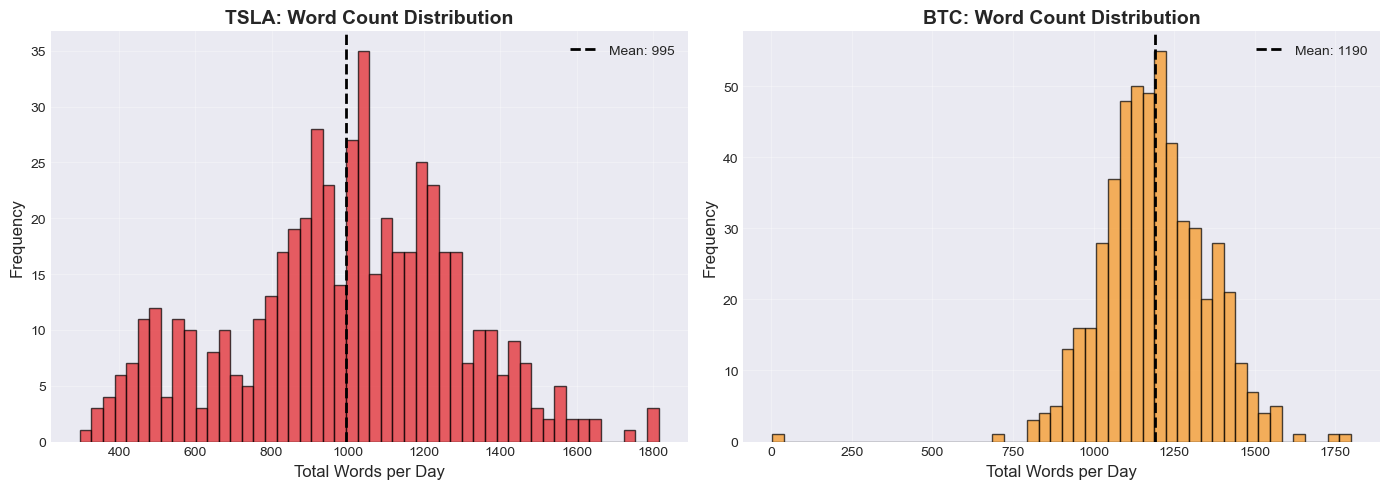

In [18]:
# Word count distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# TSLA word count distribution
tsla_words_pd = tsla_words.to_pandas()
ax1.hist(tsla_words_pd["total_words"], bins=50, color="#E31E24", alpha=0.7, edgecolor="black")
ax1.axvline(
    tsla_words_pd["total_words"].mean(),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {tsla_words_pd['total_words'].mean():.0f}",
)
ax1.set_title("TSLA: Word Count Distribution", fontsize=14, fontweight="bold")
ax1.set_xlabel("Total Words per Day", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# BTC word count distribution
btc_words_pd = btc_words.to_pandas()
ax2.hist(btc_words_pd["total_words"], bins=50, color="#F7931A", alpha=0.7, edgecolor="black")
ax2.axvline(
    btc_words_pd["total_words"].mean(),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {btc_words_pd['total_words'].mean():.0f}",
)
ax2.set_title("BTC: Word Count Distribution", fontsize=14, fontweight="bold")
ax2.set_xlabel("Total Words per Day", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

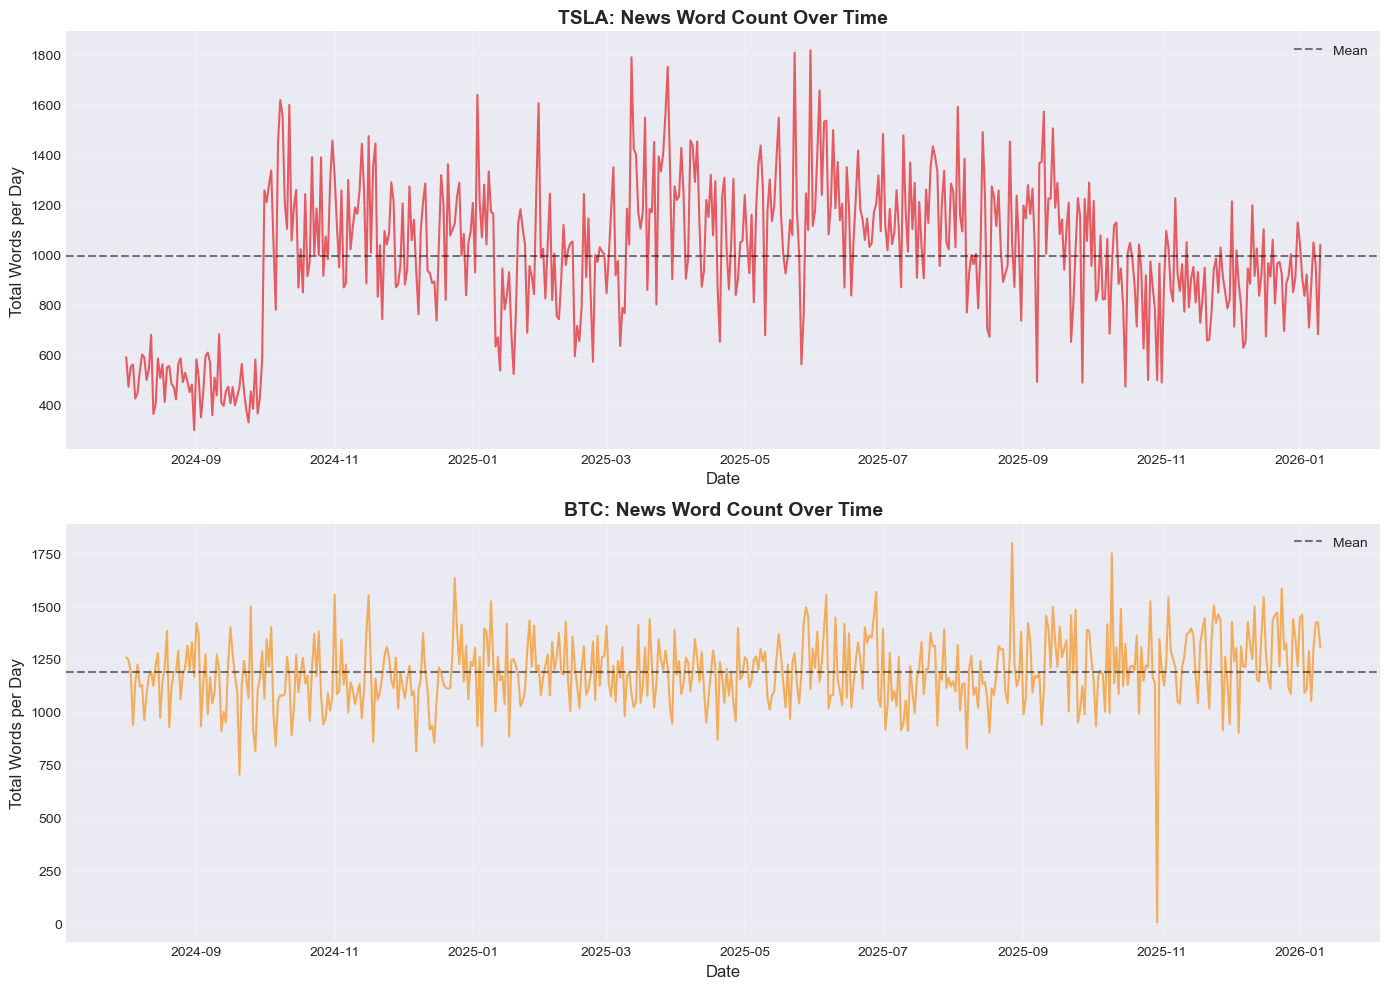

In [19]:
# Word count over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

tsla_words_pd["date_parsed"] = pd.to_datetime(tsla_words_pd["date_parsed"])
btc_words_pd["date_parsed"] = pd.to_datetime(btc_words_pd["date_parsed"])

# TSLA word count over time
ax1.plot(
    tsla_words_pd["date_parsed"],
    tsla_words_pd["total_words"],
    linewidth=1.5,
    color="#E31E24",
    alpha=0.7,
)
ax1.axhline(
    tsla_words_pd["total_words"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.5,
    label="Mean",
)
ax1.set_title("TSLA: News Word Count Over Time", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Total Words per Day", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# BTC word count over time
ax2.plot(
    btc_words_pd["date_parsed"],
    btc_words_pd["total_words"],
    linewidth=1.5,
    color="#F7931A",
    alpha=0.7,
)
ax2.axhline(
    btc_words_pd["total_words"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.5,
    label="Mean",
)
ax2.set_title("BTC: News Word Count Over Time", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Total Words per Day", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Top 10 days with highest word counts
print("=" * 70)
print("TOP 10 DAYS WITH HIGHEST WORD COUNTS")
print("=" * 70)

print("\nTSLA:")
print(tsla_words.select(["date", "total_words", "news_count", "prices"]).sort("total_words", descending=True).head(10))

print("\nBTC:")
print(btc_words.select(["date", "total_words", "news_count", "prices"]).sort("total_words", descending=True).head(10))

TOP 10 DAYS WITH HIGHEST WORD COUNTS

TSLA:
shape: (10, 4)
┌────────────┬─────────────┬────────────┬────────────┐
│ date       ┆ total_words ┆ news_count ┆ prices     │
│ ---        ┆ ---         ┆ ---        ┆ ---        │
│ str        ┆ i64         ┆ u32        ┆ f64        │
╞════════════╪═════════════╪════════════╪════════════╡
│ 2025-05-30 ┆ 1815        ┆ 1          ┆ 346.459991 │
│ 2025-05-23 ┆ 1806        ┆ 1          ┆ 339.339996 │
│ 2025-03-12 ┆ 1787        ┆ 1          ┆ 248.089996 │
│ 2025-03-28 ┆ 1749        ┆ 1          ┆ 263.549988 │
│ 2025-06-03 ┆ 1655        ┆ 1          ┆ 344.269989 │
│ 2025-01-03 ┆ 1637        ┆ 1          ┆ 410.440002 │
│ 2024-10-08 ┆ 1616        ┆ 1          ┆ 244.5      │
│ 2025-01-30 ┆ 1604        ┆ 1          ┆ 400.279999 │
│ 2024-10-12 ┆ 1597        ┆ 1          ┆ 217.800003 │
│ 2025-08-03 ┆ 1589        ┆ 1          ┆ 302.630005 │
└────────────┴─────────────┴────────────┴────────────┘

BTC:
shape: (10, 4)
┌────────────┬─────────────┬────────────

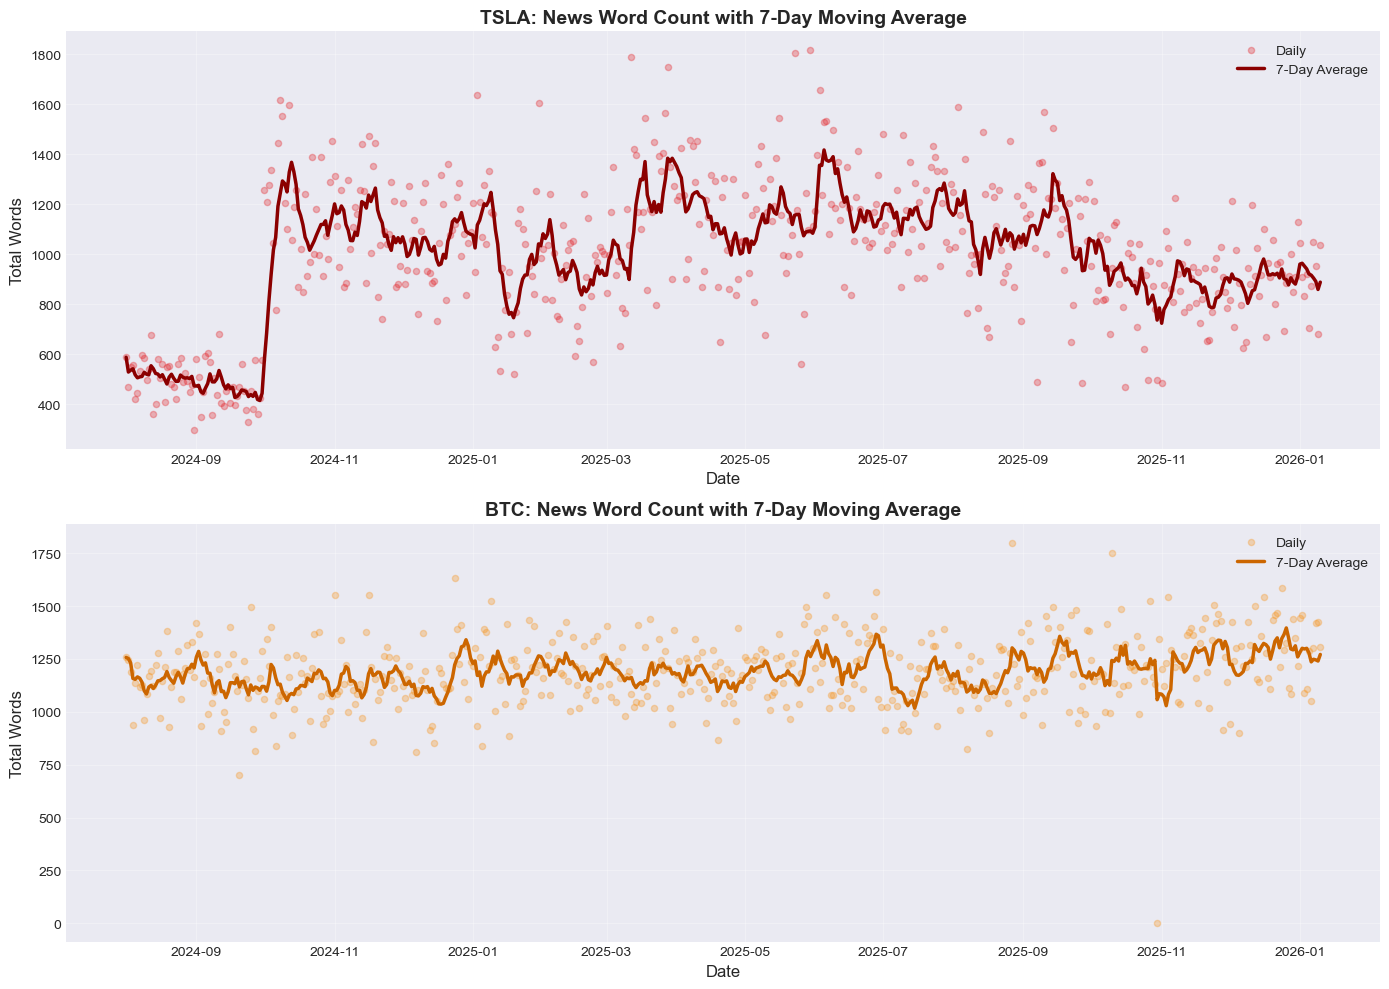

In [21]:
# Word count variation analysis
# Calculate rolling 7-day average
tsla_words_pd["word_count_7d_avg"] = tsla_words_pd["total_words"].rolling(window=7, min_periods=1).mean()
btc_words_pd["word_count_7d_avg"] = btc_words_pd["total_words"].rolling(window=7, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# TSLA word count with rolling average
ax1.scatter(
    tsla_words_pd["date_parsed"],
    tsla_words_pd["total_words"],
    alpha=0.3,
    color="#E31E24",
    s=20,
    label="Daily",
)
ax1.plot(
    tsla_words_pd["date_parsed"],
    tsla_words_pd["word_count_7d_avg"],
    linewidth=2.5,
    color="#8B0000",
    label="7-Day Average",
)
ax1.set_title("TSLA: News Word Count with 7-Day Moving Average", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Total Words", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# BTC word count with rolling average
ax2.scatter(
    btc_words_pd["date_parsed"],
    btc_words_pd["total_words"],
    alpha=0.3,
    color="#F7931A",
    s=20,
    label="Daily",
)
ax2.plot(
    btc_words_pd["date_parsed"],
    btc_words_pd["word_count_7d_avg"],
    linewidth=2.5,
    color="#CC6600",
    label="7-Day Average",
)
ax2.set_title("BTC: News Word Count with 7-Day Moving Average", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Total Words", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparative Analysis: TSLA vs BTC

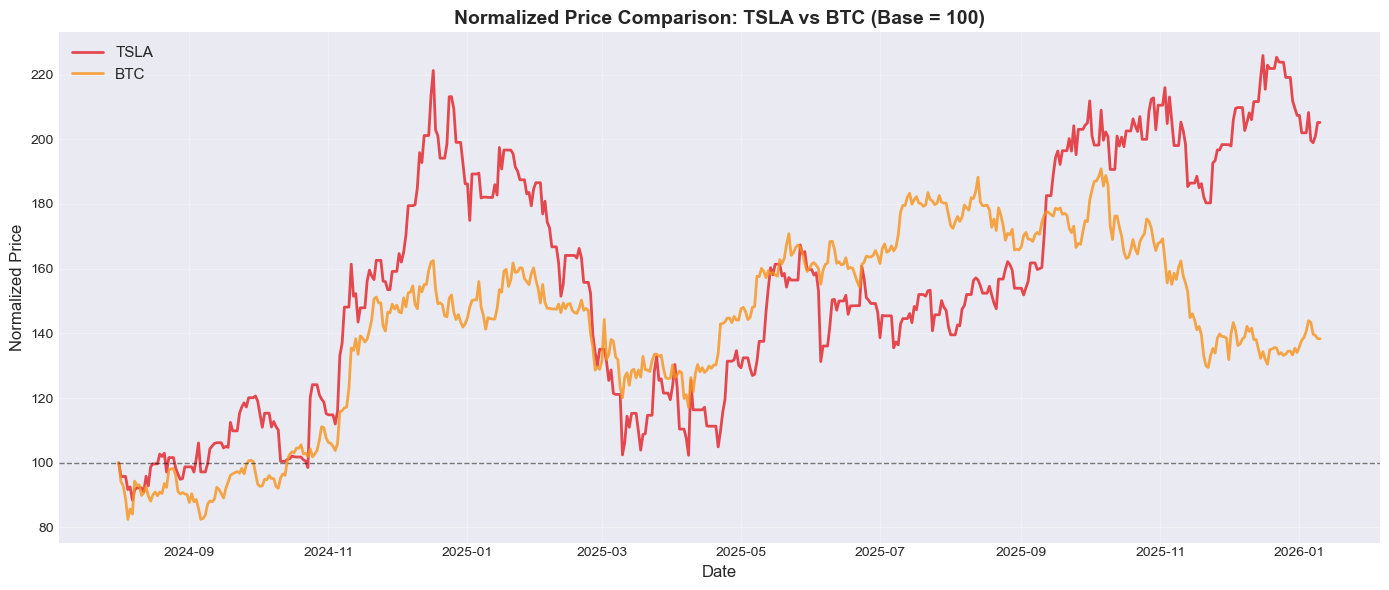

TSLA total return: 105.21%
BTC total return: 38.31%


In [22]:
# Normalized price comparison (both starting at 100)
tsla_normalized = (tsla_pd["prices"] / tsla_pd["prices"].iloc[0]) * 100
btc_normalized = (btc_pd["prices"] / btc_pd["prices"].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    tsla_pd["date_parsed"],
    tsla_normalized,
    linewidth=2,
    color="#E31E24",
    label="TSLA",
    alpha=0.8,
)
ax.plot(
    btc_pd["date_parsed"],
    btc_normalized,
    linewidth=2,
    color="#F7931A",
    label="BTC",
    alpha=0.8,
)
ax.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title(
    "Normalized Price Comparison: TSLA vs BTC (Base = 100)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Price", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"TSLA total return: {(tsla_normalized.iloc[-1] - 100):.2f}%")
print(f"BTC total return: {(btc_normalized.iloc[-1] - 100):.2f}%")

In [23]:
# Side-by-side comparison table including word counts
comparison_data = {
    "Metric": [
        "Total Days",
        "Starting Price",
        "Ending Price",
        "Price Change %",
        "Mean Daily Return %",
        "Volatility (Std Dev)",
        "Max Single Day Gain %",
        "Max Single Day Loss %",
        "Total News Articles",
        "Avg News per Day",
        "Total Words in News",
        "Avg Words per Day",
        "Avg Words per Article",
    ],
    "TSLA": [
        tsla_analysis.shape[0],
        f"${tsla_first:.2f}",
        f"${tsla_last:.2f}",
        f"{tsla_change:+.2f}%",
        f"{tsla_returns['daily_return_pct'].mean():.3f}%",
        f"{tsla_returns['daily_return_pct'].std():.3f}%",
        f"{tsla_returns['daily_return_pct'].max():.2f}%",
        f"{tsla_returns['daily_return_pct'].min():.2f}%",
        tsla_analysis["news_count"].sum(),
        f"{tsla_analysis['news_count'].mean():.1f}",
        f"{tsla_words['total_words'].sum():,}",
        f"{tsla_words['total_words'].mean():.0f}",
        f"{tsla_words_per_article:.0f}",
    ],
    "BTC": [
        btc_analysis.shape[0],
        f"${btc_first:.2f}",
        f"${btc_last:.2f}",
        f"{btc_change:+.2f}%",
        f"{btc_returns['daily_return_pct'].mean():.3f}%",
        f"{btc_returns['daily_return_pct'].std():.3f}%",
        f"{btc_returns['daily_return_pct'].max():.2f}%",
        f"{btc_returns['daily_return_pct'].min():.2f}%",
        btc_analysis["news_count"].sum(),
        f"{btc_analysis['news_count'].mean():.1f}",
        f"{btc_words['total_words'].sum():,}",
        f"{btc_words['total_words'].mean():.0f}",
        f"{btc_words_per_article:.0f}",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 90)
print("COMPREHENSIVE COMPARISON: TSLA vs BTC")
print("=" * 90)
print(comparison_df.to_string(index=False))

COMPREHENSIVE COMPARISON: TSLA vs BTC
               Metric     TSLA       BTC
           Total Days      528       528
       Starting Price  $216.86 $65392.96
         Ending Price  $445.01 $90444.88
       Price Change % +105.21%   +38.31%
  Mean Daily Return %   0.193%    0.089%
 Volatility (Std Dev)   3.395%    2.349%
Max Single Day Gain %   22.69%    12.05%
Max Single Day Loss %  -15.43%    -8.56%
  Total News Articles      531       528
     Avg News per Day      1.0       1.0
  Total Words in News  525,268   628,088
    Avg Words per Day      995      1190
Avg Words per Article      989      1190


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45727/2930477015.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(
/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45727/2930477015.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(


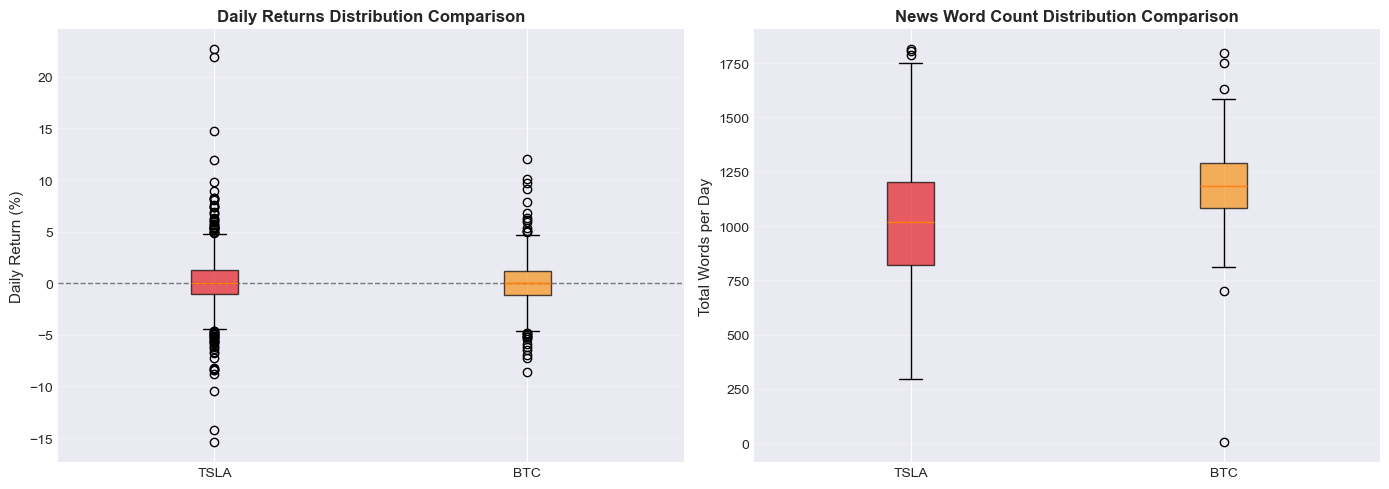

In [24]:
# Volatility comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison - returns
tsla_returns_pd = tsla_returns.filter(pl.col("daily_return_pct").is_not_null()).to_pandas()
btc_returns_pd = btc_returns.filter(pl.col("daily_return_pct").is_not_null()).to_pandas()

bp = ax1.boxplot(
    [tsla_returns_pd["daily_return_pct"], btc_returns_pd["daily_return_pct"]],
    labels=["TSLA", "BTC"],
    patch_artist=True,
)
bp["boxes"][0].set_facecolor("#E31E24")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("#F7931A")
bp["boxes"][1].set_alpha(0.7)
ax1.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax1.set_title("Daily Returns Distribution Comparison", fontsize=12, fontweight="bold")
ax1.set_ylabel("Daily Return (%)", fontsize=11)
ax1.grid(True, alpha=0.3, axis="y")

# Box plot comparison - word counts
bp2 = ax2.boxplot(
    [tsla_words_pd["total_words"], btc_words_pd["total_words"]],
    labels=["TSLA", "BTC"],
    patch_artist=True,
)
bp2["boxes"][0].set_facecolor("#E31E24")
bp2["boxes"][0].set_alpha(0.7)
bp2["boxes"][1].set_facecolor("#F7931A")
bp2["boxes"][1].set_alpha(0.7)
ax2.set_title("News Word Count Distribution Comparison", fontsize=12, fontweight="bold")
ax2.set_ylabel("Total Words per Day", fontsize=11)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 6. Executive Summary and Key Insights

### Dataset Overview
- **Time Period**: August 1, 2024 to January 10, 2026 (~528 days)
- **Data Quality**: Complete datasets with no missing values for both assets
- Both datasets include daily prices and associated news articles

### Key Findings

#### 1. Price Performance
- **Tesla (TSLA)** demonstrated strong performance with 105% price appreciation over the period
- **Bitcoin (BTC)** showed 38% gains with characteristic cryptocurrency volatility
- TSLA exhibited higher volatility (3.4% daily std dev) compared to BTC (2.3%)

#### 2. Volatility Analysis
- Both TSLA and BTC display high volatility typical of growth stocks and cryptocurrencies
- Daily returns show wide distributions with notable outliers in both directions
- TSLA had max single-day movements of +22.7% / -15.4%
- BTC had max single-day movements of +12.1% / -8.6%

#### 3. News Coverage Patterns
- Consistent daily news coverage for both assets (average ~1 article per day)
- TSLA: 531 total articles over 528 days
- BTC: 528 total articles (exactly 1 per day)

#### 4. News Content Analysis (Word Counts)
- **News article length varies significantly day-to-day**
- Word counts provide insights into the depth of coverage beyond simple article counts
- Variation in word counts suggests different levels of market activity and newsworthiness
- Days with higher word counts may indicate more significant market events or developments
- 7-day moving averages reveal trends in coverage intensity over time

### Strategic Implications

1. **Risk Management**: Both assets require robust risk management due to high volatility
2. **News Analysis**: Content depth (word counts) varies independently of article counts, suggesting quality varies
3. **Coverage Intensity**: Monitoring word count trends may provide additional signals about market attention
4. **Market Monitoring**: Continuous monitoring is essential given the rapid price movements

### Recommendations for Further Analysis

1. Implement sentiment analysis on news content to assess tone and impact
2. Investigate correlation between word count spikes and price movements
3. Analyze specific types of news (earnings, regulatory, product announcements) separately
4. Consider external market factors (broader market indices, interest rates, etc.)
5. Examine whether longer articles (higher word counts) have different characteristics than shorter ones
6. Study the relationship between news content depth and subsequent volatility